In [1]:
import numpy as np
import matplotlib.pyplot as  plt

In [2]:
def correctFunction(x):
    return 15 + 2.4*x - 0.5*x**2 - 0.35*x**3

In [3]:
npoints = 21
x_list = np.linspace(-5, 5, npoints)
data0 = np.array([x_list, correctFunction(x_list)])

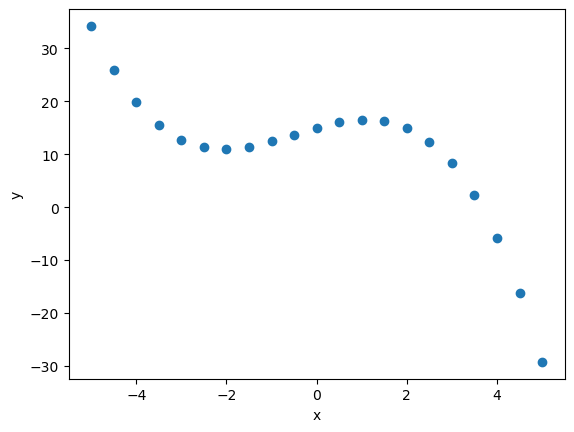

In [4]:
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(data0[0], data0[1])

In [5]:
0.1 * (2*np.random.rand(npoints) - 1)

array([ 0.01819168, -0.02335914,  0.09623582, -0.02201873,  0.08061412,
        0.07864298,  0.01778244, -0.03406578, -0.00357057, -0.00106108,
       -0.01924253, -0.00890527,  0.00304472,  0.09485965,  0.05037418,
        0.00897001,  0.01795816,  0.03984755, -0.09744229,  0.04255626,
       -0.067268  ])

In [6]:
data = np.array([data0[0] + 0.25 * (2*np.random.rand(npoints) - 1), data0[1] + 5.0 * (2*np.random.rand(npoints)-1)])

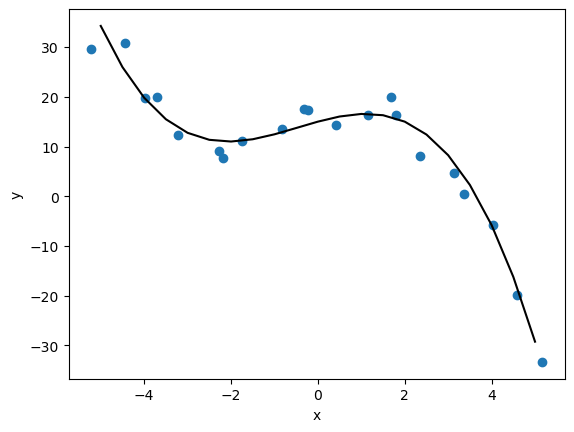

In [7]:
plt.xlabel('x')
plt.ylabel('y')

plt.plot(data0[0], data0[1], 'black')
plt.scatter(data[0], data[1])

In [8]:
def polynomialModel(x, a):
    t = 0
    for k in range(len(a)):
        t = t + a[k] * x**k
    return t

In [9]:
a0 = np.array([15, 2.4, -0.5, -0.35])
#a0 = np.array([1, 1, 1, 1])

In [10]:
npoints = 21

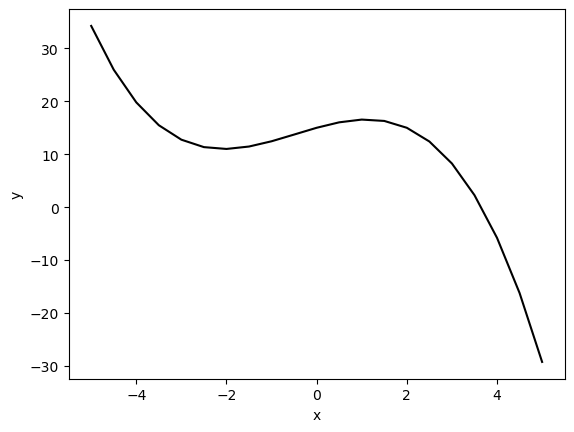

In [11]:
plt.xlabel('x')
plt.ylabel('y')

x_list = np.linspace(-5, 5, npoints)
plt.plot(x_list, polynomialModel(x_list, a0), 'black')

In [12]:
def errorFit(f, coefficients, data):
    # f: The fit function
    # coefficients: ai that we try to optimize
    # data: The data we try to fit
    error = 0
    for i in range(len(data[0])):
        error = error + (data[1, i] - f(data[0, i], coefficients))**2
        #print(error)
    return error

In [13]:
errorFit(polynomialModel, a0, data)

np.float64(227.8644319774168)

In [14]:
def errorFitGradient(f, coefficients, data):
    # f: The fit function
    # coefficients: ai that we try to optimize
    # data: The data we try to fit
    return -2 * np.array([
            np.sum(np.array([(data[1, i] - f(data[0, i], coefficients)) * data[0, i]**k for i in range(len(data[0]))])) 
        for k in range(len(coefficients))])

In [15]:
errorFitGradient(polynomialModel, a0, data)

array([  16.76770337,    1.90236823,  426.04078401, -953.59252699])

### This was an assigned exercise to try to use a ploynomial of order 5

In [16]:
iterations = 500000
h = 0.000000001
a = 2*np.random.rand(6) - 1

print(a)

for i in range(iterations):
    a = a - h * errorFitGradient(polynomialModel, a, data)

print(a)

[ 0.85744738  0.9252127  -0.20067919  0.12696414 -0.50140536  0.51114528]
[ 1.02588696e+00  9.11270053e-01  3.26238022e-01 -2.76243183e-01
 -9.75074850e-03  2.00625568e-04]


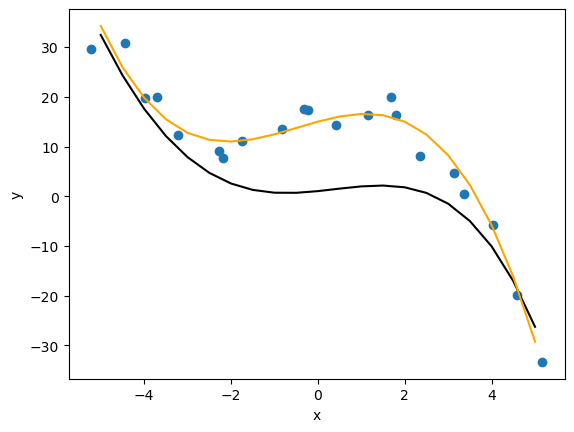

In [17]:
plt.xlabel('x')
plt.ylabel('y')

x_list = np.linspace(-5, 5, npoints)
plt.plot(x_list, polynomialModel(x_list, a), 'black')
plt.plot(x_list, polynomialModel(x_list, a0), 'orange')
plt.scatter(data[0], data[1])

In [18]:
print(errorFit(polynomialModel, a, data))
print(errorFit(polynomialModel, a0, data))

2051.4775624297104
227.8644319774168


In [19]:
print(a)
print(a0)

[ 1.02588696e+00  9.11270053e-01  3.26238022e-01 -2.76243183e-01
 -9.75074850e-03  2.00625568e-04]
[15.    2.4  -0.5  -0.35]


### Using a polynomial of order 3

In [20]:
iterations = 100000
h = 0.00001
a = 2*np.random.rand(4) - 1

print(a)

for i in range(iterations):
    a = a - h * errorFitGradient(polynomialModel, a, data)

print(a)

[ 0.54983497  0.16322947  0.30197176 -0.84741713]
[15.44459317  1.66982253 -0.588275   -0.30815172]


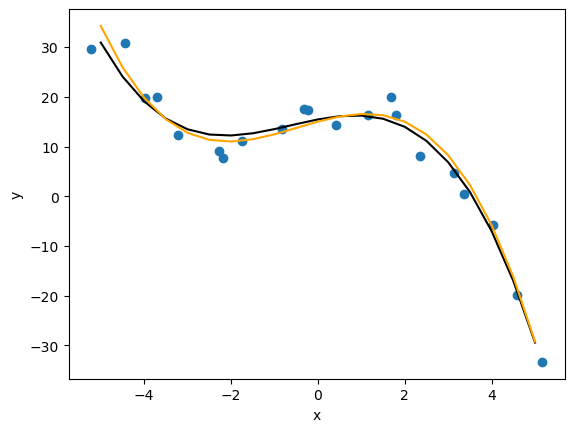

In [21]:
plt.xlabel('x')
plt.ylabel('y')

x_list = np.linspace(-5, 5, npoints)
plt.plot(x_list, polynomialModel(x_list, a), 'black')
plt.plot(x_list, polynomialModel(x_list, a0), 'orange')
plt.scatter(data[0], data[1])

In [22]:
print(errorFit(polynomialModel, a, data))
print(errorFit(polynomialModel, a0, data))

192.1398242365985
227.8644319774168


In [23]:
print(a)
print(a0)

[15.44459317  1.66982253 -0.588275   -0.30815172]
[15.    2.4  -0.5  -0.35]
